# Latent SOPE — 50 Rollouts

Scaled-up version of `latent_sope.ipynb` (Steps 0–7) with production-scale data collection.

| Parameter | `latent_sope.ipynb` | This notebook |
|-----------|--------------------|--------------|
| Oracle rollouts (K) | 10 | 50 |
| Offline rollouts (N) | 5 | 50 |
| Training epochs | 5 | 50 |
| Diffusion steps | 64 | 256 |
| Synthetic trajectories | 16 | 50 |

**Checkpoint reuse:** Each step checks for existing results and skips if found.
Set `FORCE_RERUN = True` to recompute everything from scratch.

**Estimated runtime (first run):** ~25 min total.
**Estimated runtime (cached):** ~2 min (Steps 5–7 only).

In [2]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

import numpy as np
import torch

REPO_ROOT = Path("../").resolve()
sys.path.insert(0, str(REPO_ROOT))

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
print(f"Repo root: {REPO_ROOT}")

# --- Set to True to recompute all steps from scratch ---
FORCE_RERUN = False

# --- Common paths ---
POLICY_DIR = Path("../third_party/robomimic/diffusion_policy_trained_models/test")
policy_train_dirs = sorted([d for d in POLICY_DIR.glob("*") if d.is_dir()])
assert len(policy_train_dirs) > 0, "No trained policies found."
policy_train_dir = policy_train_dirs[-1]
print(f"Using policy from: {policy_train_dir}")

# --- Common hyperparams ---
K = 50           # oracle rollouts
N_ROLLOUTS = 50  # offline rollouts
EPOCHS = 50      # diffusion training epochs
HORIZON = 60
gamma = 1.0
BATCH_SIZE = 64
NUM_TRAJS = 50   # synthetic trajectories
obs_keys = ["object", "robot0_eef_pos", "robot0_eef_quat", "robot0_gripper_qpos"]

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Device: cuda
Repo root: /home1/reishuen/latent_sope
Using policy from: ../third_party/robomimic/diffusion_policy_trained_models/test/20260309132349


## Step 0: Ground Truth (Oracle Baseline)

50 rollouts for a tighter oracle estimate (~12 min).
Saves result to JSON; skips if already computed.

In [ ]:
import json

from src.latent_sope.robomimic_interface.checkpoints import load_checkpoint
from src.latent_sope.eval.oracle import oracle_value as compute_oracle_value, save_oracle_result, load_oracle_result

oracle_path = policy_train_dir / "oracle_50.json"

if oracle_path.exists() and not FORCE_RERUN:
    oracle_result = load_oracle_result(oracle_path)
    oracle_value = oracle_result.mean_return
    oracle_returns = oracle_result.returns.tolist()
    print(f"Loaded cached oracle from {oracle_path}")
    print(f"  Oracle V^pi = {oracle_value:.3f} (std={np.std(oracle_returns):.3f}, K={len(oracle_returns)})")
else:
    ckpt = load_checkpoint(policy_train_dir.resolve(), ckpt_path="last.pth")
    oracle_result = compute_oracle_value(ckpt, num_rollouts=K, horizon=HORIZON, num_workers=0, verbose=True)
    oracle_value = oracle_result.mean_return
    oracle_returns = oracle_result.returns.tolist()

    save_oracle_result(oracle_path, oracle_result)
    print(f"Saved oracle to {oracle_path}")

print(f"\nOracle V^pi over {len(oracle_returns)} rollouts (horizon={HORIZON}, gamma={gamma}):")
print(f"  mean = {oracle_value:.3f}, std = {np.std(oracle_returns):.3f}")

## Step 1: Collect Offline Data

50 rollouts (~12 min). Saves to `rollout_latents_50/`. Skips if directory already has N_ROLLOUTS files.

In [ ]:
from src.latent_sope.robomimic_interface.rollout import (
    save_rollout_latents,
    load_rollout_latents,
    get_policy_frame_stack,
    PolicyFeatureHook,
    RolloutLatentRecorder,
)
from src.latent_sope.robomimic_interface.collect import collect_rollouts

output_dir = policy_train_dir / "rollout_latents_50"
output_dir.mkdir(exist_ok=True)
existing_rollouts = sorted(output_dir.glob("*.h5"))

if len(existing_rollouts) >= N_ROLLOUTS and not FORCE_RERUN:
    rollout_paths = existing_rollouts[:N_ROLLOUTS]
    print(f"Found {len(existing_rollouts)} existing rollouts in {output_dir} — skipping collection.")
else:
    if "ckpt" not in dir():
        ckpt = load_checkpoint(policy_train_dir.resolve(), ckpt_path="last.pth")

    collection = collect_rollouts(
        ckpt, output_dir=output_dir, num_rollouts=N_ROLLOUTS,
        horizon=HORIZON, obs_keys=obs_keys, num_workers=0, verbose=True,
    )
    rollout_paths = collection.paths
    print(f"Collected {len(rollout_paths)} rollout files in {output_dir}")

print(f"Using {len(rollout_paths)} rollout files")

## Step 2: Chunk the Offline Data

50 rollouts x ~25 chunks each = ~1250 chunks → ~19 batches of 64.
Skipped when loading diffusion model from checkpoint (Step 3 restores configs).

In [5]:
from src.latent_sope.robomimic_interface.dataset import (
    RolloutChunkDatasetConfig,
    make_rollout_chunk_dataloader,
)

ckpt_path_check = policy_train_dir / "diffusion_ckpts_50" / "sope_diffuser_latest.pt"
need_chunking = not ckpt_path_check.exists() or FORCE_RERUN

if need_chunking:
    sample_traj = load_rollout_latents(rollout_paths[0])
    latents_dim = sample_traj.latents.shape[-1]
    action_dim = sample_traj.actions.shape[-1]
    print(f"Latent dim: {latents_dim}, Action dim: {action_dim}")

    dataset_config = RolloutChunkDatasetConfig(
        chunk_size=8,
        stride=2,
        frame_stack=2,
        source="latents",
        latents_dim=latents_dim,
        action_dim=action_dim,
        normalize=True,
        return_metadata=True,
    )

    dataloader, norm_stats = make_rollout_chunk_dataloader(
        paths=rollout_paths,
        config=dataset_config,
        batch_size=BATCH_SIZE,
        shuffle=True,
        drop_last=True,
    )

    print(f"DataLoader: {len(dataloader)} batches of size {BATCH_SIZE}")
    if norm_stats is not None:
        print(f"Normalization stats: mean shape={norm_stats.mean.shape}")

    batch = next(iter(dataloader))
    for k, v in batch.items():
        if isinstance(v, torch.Tensor):
            print(f"  {k}: {v.shape} {v.dtype}")
        else:
            print(f"  {k}: {type(v).__name__}")
else:
    print("Diffusion checkpoint exists — skipping chunking (configs will be restored in Step 3).")

Latent dim: 19, Action dim: 7
DataLoader: 17 batches of size 64
Normalization stats: mean shape=(26,)
  states_from: torch.Size([64, 2, 19]) torch.float32
  actions_from: torch.Size([64, 2, 7]) torch.float32
  states_to: torch.Size([64, 9, 19]) torch.float32
  actions_to: torch.Size([64, 8, 7]) torch.float32
  metadata: dict


## Step 3: Train Chunk Diffusion

256 diffusion steps (SOPE default), 50 epochs. ~5 min estimated.
Loads from checkpoint if available; otherwise trains and saves.

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Config cross-validation passed.
[ models/temporal ] Channel dimensions: [(26, 32), (32, 64)]
[(26, 32), (32, 64)]
TemporalUnet parameters: 252,698
Training for 50 epochs...


/home1/reishuen/latent_sope/third_party/sope/opelab/core/baselines/diffusion/diffusion.py:314: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  betas * np.sqrt(alphas_cumprod_prev) / (1. - alphas_cumprod))


Epoch 1/50:   0%|          | 0/17 [00:00<?, ?it/s]

Epoch   1: mean loss = 1.3435


...

Epoch 47/50:   0%|          | 0/17 [00:00<?, ?it/s]

Epoch 48/50:   0%|          | 0/17 [00:00<?, ?it/s]

Epoch 49/50:   0%|          | 0/17 [00:00<?, ?it/s]

Epoch 50/50:   0%|          | 0/17 [00:00<?, ?it/s]

Epoch  50: mean loss = 0.9600


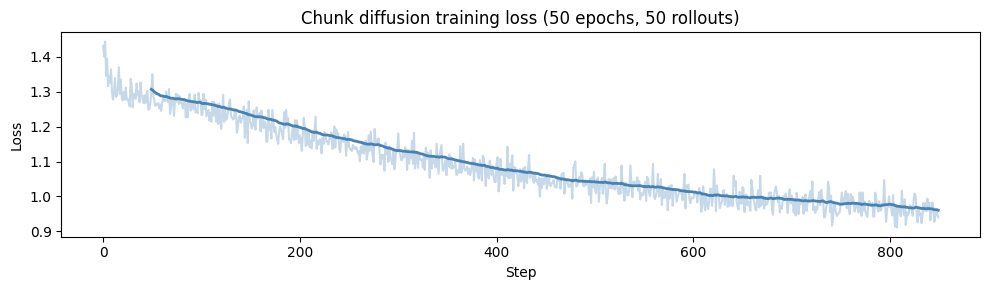

Saved checkpoint to ../third_party/robomimic/diffusion_policy_trained_models/test/20260309132349/diffusion_ckpts_50/sope_diffuser_latest.pt
  Final loss: 0.9398


In [6]:
from tqdm.auto import tqdm
from dataclasses import asdict
from src.latent_sope.diffusion.sope_diffuser import (
    SopeDiffusionConfig,
    SopeDiffuser,
    NormalizationStats as DiffusionNormStats,
    cross_validate_configs,
)

ckpt_dir = policy_train_dir / "diffusion_ckpts_50"
ckpt_path = ckpt_dir / "sope_diffuser_latest.pt"

if ckpt_path.exists() and not FORCE_RERUN:
    # ─── Load from checkpoint ───
    print(f"Loading diffusion checkpoint from {ckpt_path}")
    ckpt_payload = torch.load(str(ckpt_path), map_location=device, weights_only=False)

    diffusion_config = SopeDiffusionConfig(**ckpt_payload["diffusion_config"])
    dataset_config = RolloutChunkDatasetConfig(**ckpt_payload["dataset_config"])

    diff_norm_stats = None
    if ckpt_payload["normalization_stats"] is not None:
        ns = ckpt_payload["normalization_stats"]
        diff_norm_stats = DiffusionNormStats(mean=ns["mean"], std=ns["std"])
        norm_stats = ns  # keep for reference

    diffuser = SopeDiffuser(cfg=diffusion_config, normalization_stats=diff_norm_stats, device=device)
    diffuser.diffusion.load_state_dict(ckpt_payload["diffusion_state_dict"])
    diffuser.diffusion.eval()

    latents_dim = diffusion_config.state_dim
    action_dim = diffusion_config.action_dim
    EPOCHS = ckpt_payload["epoch"]

    print(f"  Loaded: {EPOCHS} epochs, {ckpt_payload['step']} steps")
    print(f"  state_dim={latents_dim}, action_dim={action_dim}, diffusion_steps={diffusion_config.diffusion_steps}")
else:
    # ─── Train from scratch ───
    diffusion_config = SopeDiffusionConfig(
        chunk_horizon=dataset_config.chunk_size,
        frame_stack=dataset_config.frame_stack,
        state_dim=latents_dim,
        action_dim=action_dim,
        diffusion_steps=256,
        dim_mults=(1, 2),
        attention=False,
        loss_type="l2",
        action_weight=5.0,
        predict_epsilon=True,
        lr=3e-4,
        guided=False,
    )

    cross_validate_configs(dataset_config, diffusion_config)
    print("Config cross-validation passed.")

    diff_norm_stats = None
    if norm_stats is not None:
        diff_norm_stats = DiffusionNormStats(mean=norm_stats.mean, std=norm_stats.std)

    diffuser = SopeDiffuser(cfg=diffusion_config, normalization_stats=diff_norm_stats, device=device)
    optimizer = diffuser.make_optimizer()

    n_params = sum(p.numel() for p in diffuser.diffusion.parameters())
    print(f"TemporalUnet parameters: {n_params:,}")
    print(f"Training for {EPOCHS} epochs...")

    # --- Training loop ---
    import matplotlib.pyplot as plt

    GRAD_CLIP = 1.0
    losses = []
    diffuser.diffusion.train()

    for epoch in range(1, EPOCHS + 1):
        epoch_losses = []
        for batch in tqdm(dataloader, desc=f"Epoch {epoch}/{EPOCHS}", leave=False):
            batch_dev = {
                k: v.to(device) if isinstance(v, torch.Tensor) else v
                for k, v in batch.items()
            }
            loss, info = diffuser.loss(batch_dev)
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(diffuser.diffusion.parameters(), GRAD_CLIP)
            optimizer.step()
            losses.append(loss.item())
            epoch_losses.append(loss.item())

        if epoch % 10 == 0 or epoch == 1:
            print(f"Epoch {epoch:3d}: mean loss = {np.mean(epoch_losses):.4f}")

    plt.figure(figsize=(10, 3))
    plt.plot(losses, alpha=0.3, color="steelblue")
    window = min(50, max(1, len(losses) // 5))
    if window > 1:
        smoothed = np.convolve(losses, np.ones(window) / window, mode="valid")
        plt.plot(range(window - 1, len(losses)), smoothed, color="steelblue", linewidth=2)
    plt.xlabel("Step")
    plt.ylabel("Loss")
    plt.title(f"Chunk diffusion training loss ({EPOCHS} epochs, {len(rollout_paths)} rollouts)")
    plt.tight_layout()
    plt.show()

    # --- Save checkpoint ---
    ckpt_dir.mkdir(exist_ok=True)
    ckpt_payload = {
        "diffusion_state_dict": diffuser.diffusion.state_dict(),
        "epoch": EPOCHS,
        "step": len(losses),
        "diffusion_config": asdict(diffusion_config),
        "dataset_config": asdict(dataset_config),
        "normalization_stats": {
            "mean": norm_stats.mean, "std": norm_stats.std,
        } if norm_stats is not None else None,
    }
    torch.save(ckpt_payload, str(ckpt_path))
    print(f"Saved checkpoint to {ckpt_path}")
    print(f"  Final loss: {losses[-1]:.4f}")

### Step 3b: Chunk Reconstruction Sanity Check

Denoise a batch of training chunks through the full diffusion process and compare
to ground truth. This verifies the model learned the chunk distribution before
attempting full trajectory stitching.

In [ ]:
# --- Chunk reconstruction sanity check ---
import matplotlib.pyplot as plt
from src.latent_sope.eval.metrics import l2_chunk_error

diffuser.diffusion.eval()

# Ensure dataloader exists (may have been skipped if loaded from checkpoint)
if "dataloader" not in dir():
    sample_traj = load_rollout_latents(rollout_paths[0])
    _latents_dim = sample_traj.latents.shape[-1]
    _action_dim = sample_traj.actions.shape[-1]
    _ds_cfg = RolloutChunkDatasetConfig(
        chunk_size=diffusion_config.chunk_horizon,
        stride=2,
        frame_stack=diffusion_config.frame_stack,
        source="latents",
        latents_dim=_latents_dim,
        action_dim=_action_dim,
    )
    dataloader, _ = make_rollout_chunk_dataloader(rollout_paths, _ds_cfg, batch_size=BATCH_SIZE)
    print(f"Created dataloader for chunk sanity check ({len(dataloader)} batches)")

# Grab one batch of real chunks
test_batch = next(iter(dataloader))
test_batch_dev = {k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in test_batch.items()}

# Build ground-truth normalized chunks (same as training forward pass)
cat_sf = torch.cat([test_batch_dev["states_from"], test_batch_dev["actions_from"]], dim=-1)
cat_st = torch.cat([test_batch_dev["states_to"][:, :-1, :], test_batch_dev["actions_to"]], dim=-1)
x_gt = torch.cat([cat_sf, cat_st], dim=1)  # (B, total_horizon, transition_dim)
cond = diffuser.make_cond(test_batch_dev)

# Sample from diffusion (denoise from noise, conditioned on frame_stack states)
with torch.no_grad():
    sample = diffuser.diffusion.conditional_sample(
        shape=x_gt.shape, cond=cond, guided=False, verbose=False,
    )
x_hat = sample.trajectories  # (B, total_horizon, transition_dim)

# Unnormalize both for comparison
x_gt_unnorm = diffuser.unnormalizer(x_gt).cpu().numpy()
x_hat_unnorm = diffuser.unnormalizer(x_hat).cpu().numpy()

# Compute L2 chunk error
state_dim = diffuser.state_dim
err = l2_chunk_error(x_hat_unnorm[:, :, :state_dim], x_gt_unnorm[:, :, :state_dim])
err_a = l2_chunk_error(x_hat_unnorm[:, :, state_dim:], x_gt_unnorm[:, :, state_dim:])
print(f"Chunk reconstruction L2 (states): mean={err.mean_l2:.4f}, std={err.std_l2:.4f}")
print(f"Chunk reconstruction L2 (actions): mean={err_a.mean_l2:.4f}, std={err_a.std_l2:.4f}")

# --- Visualize: overlay 3 real vs reconstructed chunks for key dims ---
fig, axes = plt.subplots(2, 3, figsize=(14, 6), sharex=True)
key_dims = [(2, "obj_pos_z"), (10, "eef_pos_x"), (12, "eef_pos_z")]

for col, (dim_idx, dim_name) in enumerate(key_dims):
    for row, (label, arr) in enumerate([("Real", x_gt_unnorm), ("Reconstructed", x_hat_unnorm)]):
        ax = axes[row, col]
        for b in range(min(5, x_gt_unnorm.shape[0])):
            ax.plot(arr[b, :, dim_idx], alpha=0.6, linewidth=1.2)
        ax.set_title(f"{label} — {dim_name}")
        ax.set_ylabel(dim_name)
        if row == 1:
            ax.set_xlabel("Chunk timestep")

fig.suptitle("Step 3b: Chunk Reconstruction (real vs denoised)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# --- Per-dimension RMSE bar chart ---
fig, ax = plt.subplots(figsize=(12, 3))
dim_labels = (
    ["obj_px", "obj_py", "obj_pz", "obj_qw", "obj_qx", "obj_qy", "obj_qz",
     "g2c_x", "g2c_y", "g2c_z", "eef_px", "eef_py", "eef_pz",
     "eef_qw", "eef_qx", "eef_qy", "eef_qz", "grip_0", "grip_1"]
)
ax.bar(range(len(err.rmse_per_dim)), err.rmse_per_dim, color="steelblue", alpha=0.8)
ax.set_xticks(range(len(dim_labels)))
ax.set_xticklabels(dim_labels, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("RMSE")
ax.set_title("Per-dimension chunk RMSE (states)")
plt.tight_layout()
plt.show()

## Step 5: Generate Synthetic Trajectories via Stitching

Generate full-length trajectories by autoregressively stitching diffusion chunks.

In [7]:
NUM_TRAJS = 50
MAX_LENGTH = HORIZON

# Sample initial states from offline rollouts
init_states = []
for i in range(NUM_TRAJS):
    traj_i = load_rollout_latents(rollout_paths[i % len(rollout_paths)])
    latents = traj_i.latents
    if latents.ndim == 3:
        latents = latents[:, 0, :]
    init_states.append(latents[0])

init_states_t = torch.tensor(np.stack(init_states), dtype=torch.float32)

print(f"Generating {NUM_TRAJS} stitched trajectories (max {MAX_LENGTH} steps)...\n")

syn_states, syn_actions, end_indices = diffuser.generate_full_trajectory(
    initial_states=init_states_t,
    max_length=MAX_LENGTH,
    guided=False,
    verbose=False,
)

print(f"Generated {NUM_TRAJS} trajectories:")
print(f"  states shape: {syn_states.shape}")
print(f"  actions shape: {syn_actions.shape}")
print(f"  state range: [{syn_states.min():.2f}, {syn_states.max():.2f}]")

Generating 50 stitched trajectories (max 60 steps)...


                                                                                                    
1 / 256 [                                                            ]   0% | 12.3 Hz
t : 255
                                                                                                    
                                                                                                    
2 / 256 [                                                            ]   0% | 21.9 Hz
t : 254
                                                                                                    
                                                                                                    
3 / 256 [                                                            ]   1% | 29.8 Hz
t : 253
                                                                                                    
                                                        

### Step 5b: Trajectory Quality Sanity Checks

Compare generated (stitched) trajectories against the real offline trajectories:
1. **Reconstruction MSE** — aggregate, per-dimension, and per-timestep
2. **Visual trajectory comparison** — real vs synthetic for key state dims
3. **Marginal statistics** — mean/std/min/max per dimension
4. **Per-step MSE plot** — shows error accumulation from autoregressive drift
5. **Success rate comparison** — real vs synthetic (using ground-truth reward)

In [ ]:
# --- Step 5b: Trajectory quality sanity checks ---
import matplotlib.pyplot as plt
from src.latent_sope.eval.metrics import trajectory_reconstruction_mse
from src.latent_sope.eval.reward_model import LiftRewardFn, score_trajectories_gt, make_lift_encoder

# ── 1. Load real trajectories (matching init states used for generation) ─────
real_states_list, real_actions_list, real_rewards_list = [], [], []
for i in range(NUM_TRAJS):
    traj_i = load_rollout_latents(rollout_paths[i % len(rollout_paths)])
    latents = traj_i.latents
    if latents.ndim == 3:
        latents = latents[:, 0, :]
    actions, rewards = traj_i.actions, traj_i.rewards
    T = latents.shape[0]
    if T >= MAX_LENGTH:
        real_states_list.append(latents[:MAX_LENGTH])
        real_actions_list.append(actions[:MAX_LENGTH])
        real_rewards_list.append(rewards[:MAX_LENGTH])
    else:
        real_states_list.append(np.pad(latents, ((0, MAX_LENGTH - T), (0, 0))))
        real_actions_list.append(np.pad(actions, ((0, MAX_LENGTH - T), (0, 0))))
        real_rewards_list.append(np.pad(rewards, (0, MAX_LENGTH - T)))

real_states = np.stack(real_states_list).astype(np.float32)
real_actions = np.stack(real_actions_list).astype(np.float32)
real_rewards = np.stack(real_rewards_list).astype(np.float32)

# ── 2. Reconstruction MSE ───────────────────────────────────────────────────
recon = trajectory_reconstruction_mse(real_states, syn_states, real_actions, syn_actions, end_indices)
print(f"Trajectory Reconstruction MSE ({recon.num_trajectories} trajs, {recon.trajectory_length} steps):")
print(f"  State MSE:  {recon.state_mse:.6f}")
print(f"  Action MSE: {recon.action_mse:.6f}")

# ── 3. Visual: real vs synthetic trajectories (key dims) ────────────────────
key_dims = [
    (2, "cube z-pos (reward signal)"),
    (12, "eef z-pos"),
    (0, "cube x-pos"),
    (10, "eef x-pos"),
]
n_show = min(4, NUM_TRAJS)  # trajectories to overlay

fig, axes = plt.subplots(len(key_dims), 1, figsize=(14, 3 * len(key_dims)), sharex=True)
for row, (dim_idx, dim_name) in enumerate(key_dims):
    ax = axes[row]
    for b in range(n_show):
        ax.plot(real_states[b, :, dim_idx], color=f"C{b}", alpha=0.8, linewidth=1.5, label=f"real #{b}" if row == 0 else None)
        ax.plot(syn_states[b, :, dim_idx], color=f"C{b}", alpha=0.8, linewidth=1.5, linestyle="--", label=f"syn #{b}" if row == 0 else None)
    ax.set_ylabel(dim_name, fontsize=9)
    if dim_idx == 2:  # cube z: show success threshold
        ax.axhline(0.84, color="red", linestyle=":", alpha=0.5, label="success threshold" if row == 0 else None)
    ax.grid(alpha=0.2)

axes[0].legend(ncol=n_show + 1, fontsize=7, loc="upper right")
axes[-1].set_xlabel("Timestep")
fig.suptitle("Step 5b: Real (solid) vs Synthetic (dashed) Trajectories", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# ── 4. Per-step MSE plot (error accumulation) ───────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(recon.state_mse_per_step, color="steelblue", linewidth=1.5, label="State MSE")
ax1.plot(recon.action_mse_per_step, color="coral", linewidth=1.5, label="Action MSE")
ax1.set_xlabel("Timestep")
ax1.set_ylabel("MSE")
ax1.set_title("Per-step MSE (error accumulation over time)")
ax1.legend()
ax1.grid(alpha=0.2)

# ── 5. Per-dimension MSE bar chart ──────────────────────────────────────────
dim_labels = [
    "obj_px", "obj_py", "obj_pz", "obj_qw", "obj_qx", "obj_qy", "obj_qz",
    "g2c_x", "g2c_y", "g2c_z", "eef_px", "eef_py", "eef_pz",
    "eef_qw", "eef_qx", "eef_qy", "eef_qz", "grip_0", "grip_1",
]
ax2.bar(range(len(recon.state_mse_per_dim)), recon.state_mse_per_dim, color="steelblue", alpha=0.8)
ax2.set_xticks(range(len(dim_labels)))
ax2.set_xticklabels(dim_labels, rotation=45, ha="right", fontsize=7)
ax2.set_ylabel("MSE")
ax2.set_title("Per-dimension state MSE")
plt.tight_layout()
plt.show()

# ── 6. Marginal statistics comparison table ─────────────────────────────────
print(f"\n{'Dim':<10} {'Real mean':>10} {'Syn mean':>10} {'Real std':>10} {'Syn std':>10} {'Real [min,max]':>20} {'Syn [min,max]':>20}")
print("-" * 102)
for d, label in enumerate(dim_labels):
    r, s = real_states[:, :, d], syn_states[:, :, d]
    print(f"{label:<10} {r.mean():10.4f} {s.mean():10.4f} {r.std():10.4f} {s.std():10.4f} "
          f"[{r.min():7.3f}, {r.max():7.3f}]  [{s.min():7.3f}, {s.max():7.3f}]")

# ── 7. Success rate comparison ───────────────────────────────────────────────
encoder = make_lift_encoder(obs_keys=obs_keys)
reward_fn = LiftRewardFn(table_height=0.8, height_threshold=0.04)

# Real success: per-trajectory, did the cube ever get lifted?
real_success = []
for i in range(NUM_TRAJS):
    cube_z = real_states[i, :, 2]
    real_success.append(float((cube_z > reward_fn.success_z).any()))
real_success_rate = np.mean(real_success)

# Synthetic success: same check on generated trajectories
syn_success = []
for i in range(NUM_TRAJS):
    cube_z = syn_states[i, :, 2]
    syn_success.append(float((cube_z > reward_fn.success_z).any()))
syn_success_rate = np.mean(syn_success)

print(f"\nSuccess rate comparison:")
print(f"  Real trajectories:      {real_success_rate:.1%} ({int(sum(real_success))}/{NUM_TRAJS})")
print(f"  Synthetic trajectories: {syn_success_rate:.1%} ({int(sum(syn_success))}/{NUM_TRAJS})")

# ── 8. Marginal distribution: cube z histogram ──────────────────────────────
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(real_states[:, :, 2].ravel(), bins=60, alpha=0.6, density=True, label="Real", color="steelblue")
ax.hist(syn_states[:, :, 2].ravel(), bins=60, alpha=0.6, density=True, label="Synthetic", color="coral")
ax.axvline(reward_fn.success_z, color="red", linestyle=":", label=f"Success threshold ({reward_fn.success_z})")
ax.set_xlabel("Cube z-position")
ax.set_ylabel("Density")
ax.set_title("Marginal distribution: cube z-position (real vs synthetic)")
ax.legend()
plt.tight_layout()
plt.show()

## Step 6: Score Trajectories (Ground-Truth Reward)

Score synthetic trajectories using the analytical Lift reward function:
`cube_z > table_height + 0.04` → reward 1.0, else 0.0.

Decodes latents → obs dict via `LowDimConcatEncoder`, then checks cube z-position directly.

In [8]:
from src.latent_sope.eval.reward_model import LiftRewardFn, score_trajectories_gt, make_lift_encoder

# Build encoder configured for Lift obs decoding (single-frame dims, not frame_stack)
encoder = make_lift_encoder(obs_keys=obs_keys)

# Ground-truth reward: cube z > 0.84
reward_fn = LiftRewardFn(table_height=0.8, height_threshold=0.04)
print(f"Reward function: {reward_fn}")

synthetic_returns, synthetic_rewards = score_trajectories_gt(
    reward_fn=reward_fn,
    encoder=encoder,
    states=syn_states,
    actions=syn_actions,
    gamma=gamma,
)

print(f"\nSynthetic trajectory returns (gamma={gamma}):")
print(f"  mean = {synthetic_returns.mean():.3f}, std = {synthetic_returns.std():.3f}")
print(f"  per-trajectory (first 10): {[f'{r:.2f}' for r in synthetic_returns[:10]]}")

# Diagnostic: cube z-positions in generated trajectories
obs_decoded = encoder.decode_to_obs_dict(syn_states[0])
cube_z = obs_decoded["object"][:, 2]
print(f"\nDiagnostic — trajectory 0 cube z-positions:")
print(f"  range: [{cube_z.min():.4f}, {cube_z.max():.4f}]")
print(f"  success threshold: {reward_fn.success_z:.4f}")
print(f"  steps above threshold: {(cube_z > reward_fn.success_z).sum()} / {len(cube_z)}")

Reward function: LiftRewardFn(table_height=0.8, height_threshold=0.04, success_z=0.8400)

Synthetic trajectory returns (gamma=1.0):
  mean = 31.020, std = 4.357
  per-trajectory (first 10): ['31.00', '29.00', '34.00', '35.00', '25.00', '33.00', '28.00', '31.00', '28.00', '30.00']

Diagnostic — trajectory 0 cube z-positions:
  range: [-17.9408, 21.6462]
  success threshold: 0.8400
  steps above threshold: 31 / 60


## Step 7: Evaluate the OPE Estimate

Compare OPE estimate to oracle ground truth.

In [9]:
from src.latent_sope.eval.metrics import ope_eval

result = ope_eval(oracle_value, synthetic_returns)

print("=" * 50)
print("OPE Evaluation (50 rollouts)")
print("=" * 50)
print(f"  Oracle V^pi:      {result.oracle_value:.3f}")
print(f"  OPE estimate:     {result.ope_estimate:.3f} (std={result.ope_std:.3f})")
print(f"  MSE:              {result.mse:.6f}")
print(f"  Relative error:   {result.relative_error:.2%}")
print("=" * 50)

OPE Evaluation (50 rollouts)
  Oracle V^pi:      0.540
  OPE estimate:     31.020 (std=4.357)
  MSE:              929.030400
  Relative error:   5644.44%


In [ ]:
# --- Step 7b: OPE summary visualization ---
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Oracle vs OPE estimate bar chart
ax = axes[0]
bars = ax.bar(["Oracle V^pi", "OPE Estimate"], [result.oracle_value, result.ope_estimate],
              color=["steelblue", "coral"], alpha=0.8, width=0.5)
ax.errorbar(1, result.ope_estimate, yerr=result.ope_std, fmt="none", color="black", capsize=8, linewidth=2)
ax.set_ylabel("Policy Value")
ax.set_title(f"OPE vs Oracle (rel. error: {result.relative_error:.1%})")
ax.set_ylim(0, max(result.oracle_value, result.ope_estimate) * 1.3 + 0.1)

# 2. Distribution of synthetic returns
ax = axes[1]
ax.hist(synthetic_returns, bins=20, alpha=0.7, color="coral", edgecolor="white")
ax.axvline(result.oracle_value, color="steelblue", linewidth=2, linestyle="--", label=f"Oracle = {result.oracle_value:.3f}")
ax.axvline(result.ope_estimate, color="coral", linewidth=2, linestyle="-", label=f"OPE = {result.ope_estimate:.3f}")
ax.set_xlabel("Trajectory Return")
ax.set_ylabel("Count")
ax.set_title("Distribution of Synthetic Returns")
ax.legend(fontsize=8)

# 3. Summary table as text
ax = axes[2]
ax.axis("off")
summary = (
    f"Oracle V^pi:      {result.oracle_value:.4f}\n"
    f"OPE Estimate:     {result.ope_estimate:.4f}\n"
    f"OPE Std:          {result.ope_std:.4f}\n"
    f"MSE:              {result.mse:.6f}\n"
    f"Relative Error:   {result.relative_error:.2%}\n"
    f"\n--- Sanity Checks ---\n"
    f"Real success:     {real_success_rate:.1%}\n"
    f"Syn success:      {syn_success_rate:.1%}\n"
    f"State recon MSE:  {recon.state_mse:.6f}\n"
    f"Action recon MSE: {recon.action_mse:.6f}"
)
ax.text(0.1, 0.5, summary, transform=ax.transAxes, fontsize=10,
        verticalalignment="center", fontfamily="monospace",
        bbox=dict(boxstyle="round,pad=0.5", facecolor="lightyellow", alpha=0.8))
ax.set_title("Summary")

fig.suptitle("Step 7: OPE Evaluation Summary", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()